# Keyword Extraction Pipeline
## FYE Town Hall Meeting Survey Analysis

**Author:** Student Researcher  
**Project:** First Year Experience Research and Engagement  
**Institution:** California State University, Chico  
**Date:** April 2026

---

## Notebook Overview

This notebook extracts salient keywords from THM survey responses using TF-IDF (Term Frequency-Inverse Document Frequency).

### Objectives:
1. Load preprocessed token data from Google Drive
2. Extract top keywords globally across all responses
3. Identify top keywords per semester to track trends
4. Extract category-specific keywords per Question_Category
5. Analyze keyword evolution over time
6. Generate visualizations and save outputs to Google Drive

### Why TF-IDF?
- Balances term frequency with document frequency
- Highlights distinctive terms (not just common words)
- Simple, interpretable, and computationally efficient
- Industry standard for keyword extraction

---
## 1. Environment Setup

In [3]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Word cloud (optional, for visualization)
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("⚠ wordcloud not installed - word cloud visualizations will be skipped")

from tqdm.auto import tqdm

# Project imports
sys.path.append('..')
from utils.gdrive_auth import DriveDataLoader
from config import PREPROCESSED_DATA_FOLDER_ID, MAIN_FOLDER_ID, GDRIVE_FILES

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Imports successful")

✓ Imports successful


---
## 2. Load Preprocessed Data from Google Drive

In [4]:
print("Initializing Google Drive connection...")
loader = DriveDataLoader()

# Run access check
all_ok = loader.run_full_check(
    main_folder_id   = MAIN_FOLDER_ID,
    output_folder_id = PREPROCESSED_DATA_FOLDER_ID,
    gdrive_files = GDRIVE_FILES
)

if not all_ok:
    raise SystemExit('\n⛔ Access check failed. Fix the issues above before proceeding.')

Initializing Google Drive connection...

  FYE PROJECT — GOOGLE DRIVE ACCESS CHECK

GOOGLE DRIVE AUTHENTICATION

🔐 You will be prompted to log in with your Google account
📋 Make sure you have access to the THM_Survey_Data folder

Steps:
  1. Browser will open
  2. Select your Google account
  3. Click 'Allow' to grant access
  4. Return here to continue


→ Refreshing expired token...

✓ AUTHENTICATED AS: hvhasabnis@csuchico.edu

✓ Ready to load data from Google Drive

  🔍 Checking READ access... ✅  (2 files visible)
  🔍 Checking WRITE access... ✅

  🔍 Verifying all dataset files...
    ✅  text_prepared        — THM_All_Semesters_TEXT_PREPARED (315 KB)
    ✅  quant_prepared       — THM_All_Semesters_QUANTITATIVE_PREPARED (17 KB)
    ✅  fall_2022            — THM_Fall_2022 (60 KB)
    ✅  spring_2023          — THM_Spring_2023 (63 KB)
    ✅  fall_2023            — THM_Fall_2023 (33 KB)
    ✅  spring_2024          — THM_Spring_2024 (23 KB)
    ✅  fall_2024            — THM_Fall_2024 (61 K

In [5]:
print("Loading preprocessed tokens from Drive...")

# Find the preprocessed_tokens.csv file
file_list = loader.drive.ListFile({
    'q': f"'{PREPROCESSED_DATA_FOLDER_ID}' in parents and trashed=false and title='preprocessed_tokens.csv'"
}).GetList()

if not file_list:
    raise FileNotFoundError("preprocessed_tokens.csv not found in Drive. Run 02_text_preprocessing first.")

file_id = file_list[0]['id']
df = loader.read_csv(file_id, label='preprocessed_tokens')

print(f"\nDataset loaded successfully!")
print(f"  Total documents: {len(df):,}")
print(f"  Columns: {list(df.columns)}")
print(f"  Semesters: {df['Semester'].nunique()}")
print(f"  Question Categories: {df['Question_Category'].nunique()}")

Loading preprocessed tokens from Drive...
  [preprocessed_tokens] Loading CSV (ID: 1vMIOAImKlQFRjm8yaOq...)... ✓ (3585, 4)

Dataset loaded successfully!
  Total documents: 3,585
  Columns: ['Semester', 'Question_Category', 'tokens', 'tokens_text']
  Semesters: 7
  Question Categories: 11


In [6]:
# Filter out empty documents
df = df[df['tokens_text'].notna() & (df['tokens_text'].str.strip() != '')].copy()
print(f"\nDocuments with content: {len(df):,}")


Documents with content: 3,585


---
## 3. Global Keyword Extraction

Extract the top 20 keywords across the entire dataset.

In [7]:
print("Extracting global keywords using TF-IDF...\n")

# Create TF-IDF vectorizer
global_vectorizer = TfidfVectorizer(
    max_features=1000,    # Keep top 1000 features
    max_df=0.7,           # Ignore terms in >70% of docs
    min_df=5,             # Ignore terms in <5 docs
    stop_words=None       # Already preprocessed
)

# Fit on all documents
tfidf_matrix = global_vectorizer.fit_transform(df['tokens_text'])
feature_names = global_vectorizer.get_feature_names_out()

# Calculate mean TF-IDF score for each term
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

# Create DataFrame
global_keywords = pd.DataFrame({
    'keyword': feature_names,
    'tfidf_score': mean_tfidf
}).sort_values('tfidf_score', ascending=False)

print("TOP 20 GLOBAL KEYWORDS")
print("=" * 50)
for idx, row in global_keywords.head(20).iterrows():
    print(f"  {row['keyword']:20s} {row['tfidf_score']:.4f}")

# Save top 20 for output
df_global_keywords = global_keywords.head(20).copy()
df_global_keywords['rank'] = range(1, 21)

Extracting global keywords using TF-IDF...

TOP 20 GLOBAL KEYWORDS
  town                 0.0622
  hall                 0.0620
  policy               0.0542
  describe             0.0523
  meeting              0.0514
  event                0.0450
  confidence           0.0419
  not                  0.0411
  community            0.0398
  help                 0.0390
  experience           0.0382
  change               0.0379
  more                 0.0366
  question             0.0362
  feel                 0.0360
  topic                0.0353
  accurately           0.0352
  response             0.0352
  chico                0.0346
  connection           0.0341


---
## 4. Keywords by Semester

Extract top keywords for each semester to identify trends.

In [8]:
print("\nExtracting keywords per semester...\n")

semester_keywords = []
semesters = sorted(df['Semester'].unique())

for semester in tqdm(semesters, desc="Processing semesters"):
    # Get documents for this semester
    semester_docs = df[df['Semester'] == semester]['tokens_text'].tolist()
    
    if len(semester_docs) < 5:
        print(f"  ⚠ Skipping {semester}: only {len(semester_docs)} documents")
        continue
    
    # Create TF-IDF vectorizer for this semester
    vectorizer = TfidfVectorizer(
        max_features=500,
        max_df=0.7,
        min_df=2,
        stop_words=None
    )
    
    tfidf = vectorizer.fit_transform(semester_docs)
    features = vectorizer.get_feature_names_out()
    mean_scores = np.asarray(tfidf.mean(axis=0)).flatten()
    
    # Get top 15 keywords
    top_indices = mean_scores.argsort()[-15:][::-1]
    
    for rank, idx in enumerate(top_indices, 1):
        semester_keywords.append({
            'Semester': semester,
            'rank': rank,
            'keyword': features[idx],
            'tfidf_score': mean_scores[idx]
        })

df_semester_keywords = pd.DataFrame(semester_keywords)
print(f"\n✓ Extracted keywords for {df_semester_keywords['Semester'].nunique()} semesters")


Extracting keywords per semester...



Processing semesters: 100%|██████████| 7/7 [00:00<00:00, 24.77it/s]


✓ Extracted keywords for 7 semesters


In [9]:
# Display top 5 keywords per semester
print("\nTOP 5 KEYWORDS PER SEMESTER")
print("=" * 60)

for semester in semesters:
    top5 = df_semester_keywords[
        (df_semester_keywords['Semester'] == semester) & 
        (df_semester_keywords['rank'] <= 5)
    ].sort_values('rank')
    
    if len(top5) > 0:
        keywords = ', '.join(top5['keyword'].tolist())
        print(f"  {semester:15s}: {keywords}")


TOP 5 KEYWORDS PER SEMESTER
  Fall_2022      : section, pol, 155, take, better
  Fall_2023      : topic, can, more, talk, learned
  Fall_2024      : learned, not, people, very, more
  Fall_2025      : confidence, connection, policy, change, community
  Spring_2023    : mean, section, pol, 155, take
  Spring_2024    : change, check, apply, community, topic
  Spring_2025    : chico, meaningful, student, hall, town


---
## 5. Keywords by Question Category

In [10]:
print("\nExtracting keywords per Question Category...\n")

category_keywords = []
categories = df['Question_Category'].unique()

for category in tqdm(categories, desc="Processing categories"):
    # Get documents for this category
    category_docs = df[df['Question_Category'] == category]['tokens_text'].tolist()
    
    if len(category_docs) < 5:
        print(f"  ⚠ Skipping {category}: only {len(category_docs)} documents")
        continue
    
    # Create TF-IDF vectorizer
    vectorizer = TfidfVectorizer(
        max_features=500,
        max_df=0.7,
        min_df=2,
        stop_words=None
    )
    
    tfidf = vectorizer.fit_transform(category_docs)
    features = vectorizer.get_feature_names_out()
    mean_scores = np.asarray(tfidf.mean(axis=0)).flatten()
    
    # Get top 15 keywords
    top_indices = mean_scores.argsort()[-15:][::-1]
    
    for rank, idx in enumerate(top_indices, 1):
        category_keywords.append({
            'Question_Category': category,
            'rank': rank,
            'keyword': features[idx],
            'tfidf_score': mean_scores[idx]
        })

df_category_keywords = pd.DataFrame(category_keywords)
print(f"\n✓ Extracted keywords for {df_category_keywords['Question_Category'].nunique()} categories")


Extracting keywords per Question Category...



Processing categories: 100%|██████████| 11/11 [00:00<00:00, 41.46it/s]


✓ Extracted keywords for 11 categories


In [11]:
# Display top 5 keywords per category
print("\nTOP 5 KEYWORDS PER QUESTION CATEGORY")
print("=" * 60)

for category in sorted(df_category_keywords['Question_Category'].unique()):
    top5 = df_category_keywords[
        (df_category_keywords['Question_Category'] == category) & 
        (df_category_keywords['rank'] <= 5)
    ].sort_values('rank')
    
    if len(top5) > 0:
        keywords = ', '.join(top5['keyword'].tolist())
        print(f"  {category:30s}: {keywords}")


TOP 5 KEYWORDS PER QUESTION CATEGORY
  Casual_Description            : people, topic, very, talk, more
  Community_Connection          : people, more, like, connected, felt
  Confidence                    : change, academic, creating, more, community
  Learning_Action               : way, can, change, people, issue
  Learning_Breakout             : more, fall, people, different, topic
  Learning_Civic                : organization, topic, can, student, many
  Learning_General              : people, table, discussion, lot, different
  Motivation                    : hall, town, section, pol, 155
  Other                         : event, policy, meaningful, topic, element
  Personal_Meaning              : chico, policy, student, experience, topic
  Suggestions_Improvement       : more, time, think, fall, would


---
## 6. Keyword Trend Analysis

Track how top global keywords evolve over semesters.

In [12]:
print("\nAnalyzing keyword trends over time...\n")

# Get top 10 global keywords to track
top_keywords = df_global_keywords.head(10)['keyword'].tolist()

trend_data = []

for semester in semesters:
    semester_docs = df[df['Semester'] == semester]['tokens_text'].tolist()
    
    if len(semester_docs) < 5:
        continue
    
    # Compute TF-IDF for this semester
    vectorizer = TfidfVectorizer(
        vocabulary=top_keywords,  # Only compute for top keywords
        stop_words=None
    )
    
    tfidf = vectorizer.fit_transform(semester_docs)
    mean_scores = np.asarray(tfidf.mean(axis=0)).flatten()
    
    for keyword, score in zip(top_keywords, mean_scores):
        trend_data.append({
            'Semester': semester,
            'keyword': keyword,
            'tfidf_score': score
        })

df_trends = pd.DataFrame(trend_data)
print(f"✓ Computed trends for {len(top_keywords)} keywords across {len(semesters)} semesters")


Analyzing keyword trends over time...

✓ Computed trends for 10 keywords across 7 semesters


In [13]:
# Identify emerging and declining keywords
print("\nKEYWORD TREND INSIGHTS")
print("=" * 60)

# Calculate change from first to last semester
first_semester = semesters[0]
last_semester = semesters[-1]

changes = []
for keyword in top_keywords:
    first_score = df_trends[
        (df_trends['Semester'] == first_semester) & 
        (df_trends['keyword'] == keyword)
    ]['tfidf_score'].values
    
    last_score = df_trends[
        (df_trends['Semester'] == last_semester) & 
        (df_trends['keyword'] == keyword)
    ]['tfidf_score'].values
    
    if len(first_score) > 0 and len(last_score) > 0:
        change = last_score[0] - first_score[0]
        pct_change = (change / first_score[0] * 100) if first_score[0] > 0 else 0
        changes.append({
            'keyword': keyword,
            'change': change,
            'pct_change': pct_change
        })

changes_df = pd.DataFrame(changes).sort_values('pct_change', ascending=False)

print(f"\nEmerging Keywords ({first_semester} → {last_semester}):")
for idx, row in changes_df.head(3).iterrows():
    print(f"  ↑ {row['keyword']:15s} (+{row['pct_change']:5.1f}%)")

print(f"\nDeclining Keywords ({first_semester} → {last_semester}):")
for idx, row in changes_df.tail(3).iterrows():
    print(f"  ↓ {row['keyword']:15s} ({row['pct_change']:5.1f}%)")


KEYWORD TREND INSIGHTS

Emerging Keywords (Fall_2022 → Spring_2025):
  ↑ event           (+827.6%)
  ↑ community       (+425.9%)
  ↑ not             (+274.1%)

Declining Keywords (Fall_2022 → Spring_2025):
  ↓ meeting         (-46.4%)
  ↓ hall            (-57.1%)
  ↓ town            (-57.2%)


---
## 7. Visualizations

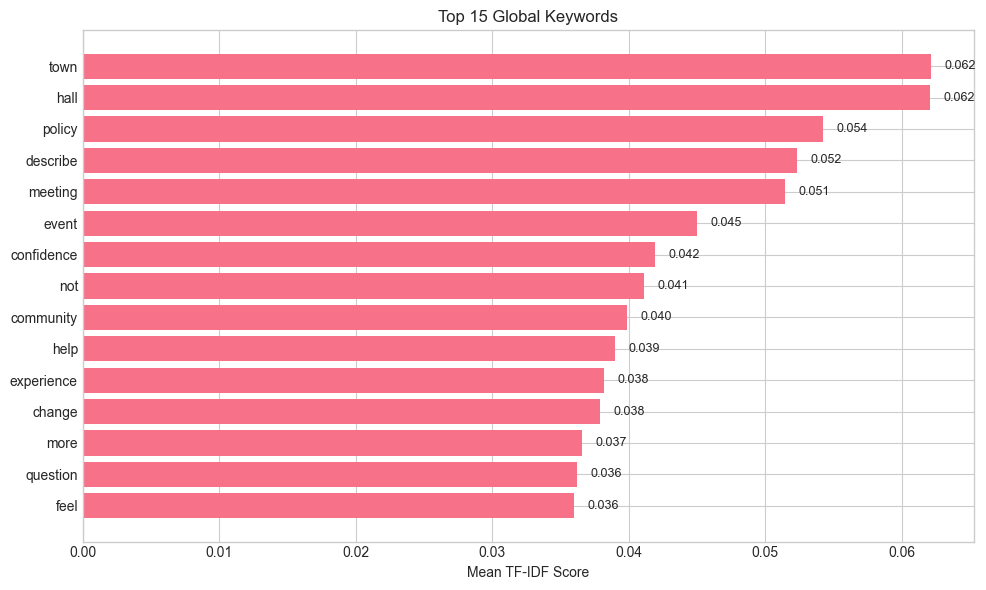

✓ Global keywords chart saved


In [14]:
# Create output directory
output_dir = Path('../outputs/04_keyword_extraction')
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Global keywords bar chart
fig, ax = plt.subplots(figsize=(10, 6))

top15 = df_global_keywords.head(15)
bars = ax.barh(range(len(top15)), top15['tfidf_score'].values)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['keyword'].values)
ax.set_xlabel('Mean TF-IDF Score')
ax.set_title('Top 15 Global Keywords')
ax.invert_yaxis()

# Add score labels
for i, (bar, score) in enumerate(zip(bars, top15['tfidf_score'].values)):
    ax.text(score + 0.001, i, f'{score:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / 'global_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Global keywords chart saved")

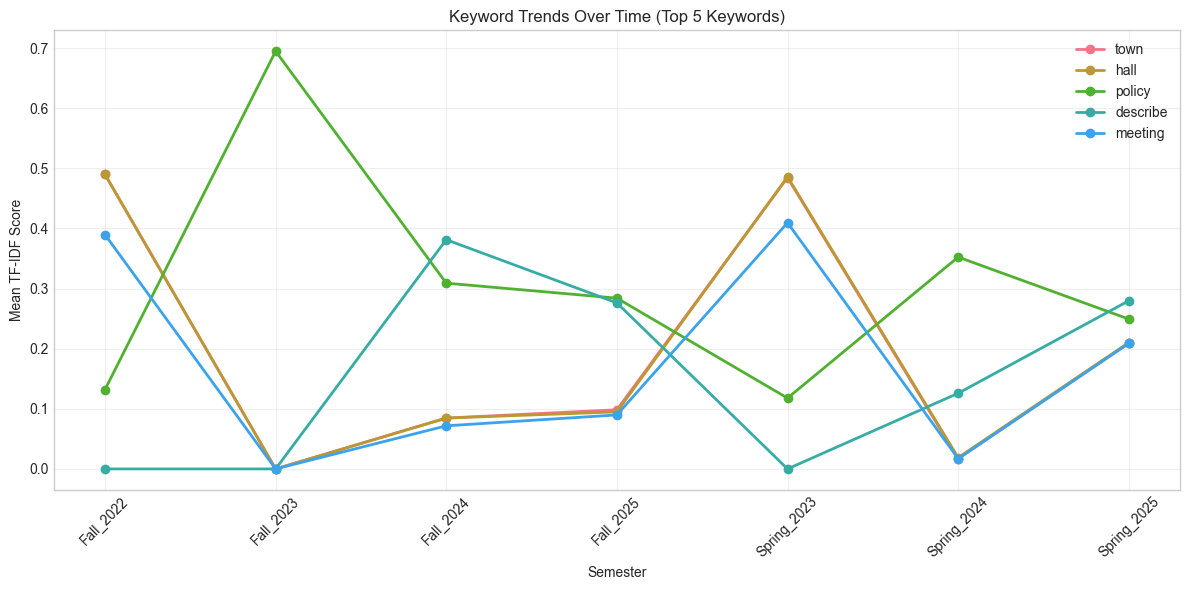

✓ Keyword trends chart saved


In [15]:
# 2. Keyword trends over time
fig, ax = plt.subplots(figsize=(12, 6))

# Plot top 5 keywords
for keyword in top_keywords[:5]:
    keyword_data = df_trends[df_trends['keyword'] == keyword].sort_values('Semester')
    ax.plot(keyword_data['Semester'], keyword_data['tfidf_score'], 
            marker='o', label=keyword, linewidth=2)

ax.set_xlabel('Semester')
ax.set_ylabel('Mean TF-IDF Score')
ax.set_title('Keyword Trends Over Time (Top 5 Keywords)')
ax.legend(loc='best')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'keyword_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Keyword trends chart saved")

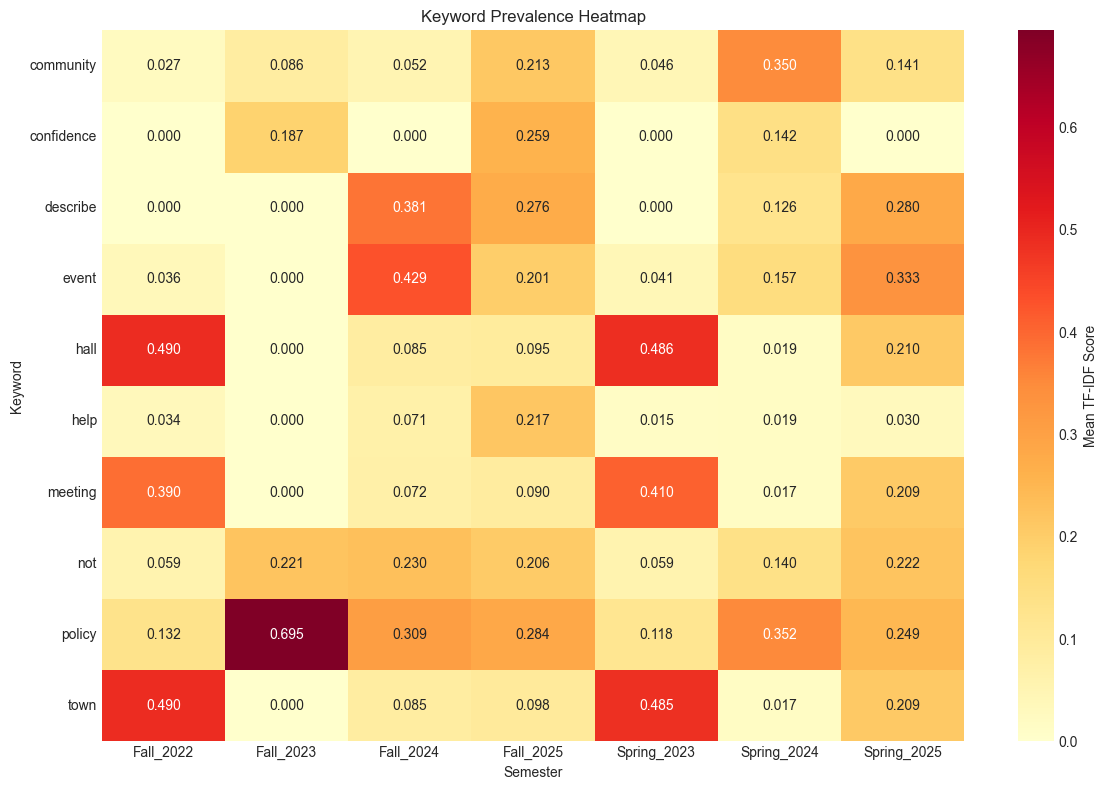

✓ Keyword heatmap saved


In [16]:
# 3. Semester × Keyword heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Pivot for heatmap
pivot = df_trends.pivot(index='keyword', columns='Semester', values='tfidf_score')

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Mean TF-IDF Score'})
ax.set_xlabel('Semester')
ax.set_ylabel('Keyword')
ax.set_title('Keyword Prevalence Heatmap')

plt.tight_layout()
plt.savefig(output_dir / 'keyword_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Keyword heatmap saved")


Generating word cloud...


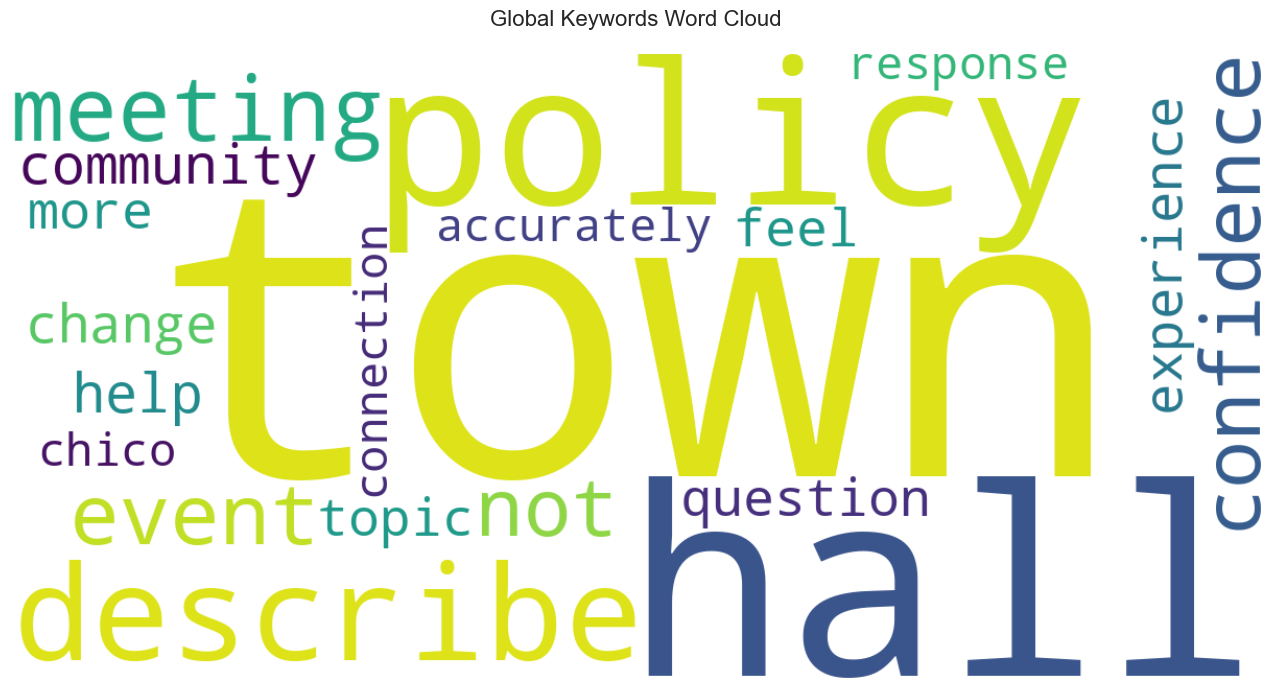

✓ Word cloud saved


In [17]:
# 4. Word cloud (if available)
if WORDCLOUD_AVAILABLE:
    print("\nGenerating word cloud...")
    
    # Create word frequency dict from global keywords
    word_freq = dict(zip(df_global_keywords['keyword'], df_global_keywords['tfidf_score']))
    
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        colormap='viridis',
        relative_scaling=0.5,
        min_font_size=10
    ).generate_from_frequencies(word_freq)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Global Keywords Word Cloud', fontsize=16, pad=20)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Word cloud saved")
else:
    print("\n⚠ Skipping word cloud (wordcloud package not installed)")

---
## 8. Save Outputs

In [18]:
print("\nPreparing output files...\n")

print(f"Output files:")
print(f"  keywords_tfidf_global.csv: {len(df_global_keywords):,} rows")
print(f"  keywords_by_semester.csv: {len(df_semester_keywords):,} rows")
print(f"  keywords_by_category.csv: {len(df_category_keywords):,} rows")
print(f"  keyword_trends.csv: {len(df_trends):,} rows")


Preparing output files...

Output files:
  keywords_tfidf_global.csv: 20 rows
  keywords_by_semester.csv: 105 rows
  keywords_by_category.csv: 158 rows
  keyword_trends.csv: 70 rows


In [19]:
# Save locally
df_global_keywords.to_csv(output_dir / 'keywords_tfidf_global.csv', index=False)
df_semester_keywords.to_csv(output_dir / 'keywords_by_semester.csv', index=False)
df_category_keywords.to_csv(output_dir / 'keywords_by_category.csv', index=False)
df_trends.to_csv(output_dir / 'keyword_trends.csv', index=False)

print("✓ Files saved locally")

✓ Files saved locally


In [20]:
print("\nUploading to Google Drive...\n")

if loader._write_ok:
    csv_files = [
        ('keywords_tfidf_global.csv', 'Global keywords'),
        ('keywords_by_semester.csv', 'Keywords by semester'),
        ('keywords_by_category.csv', 'Keywords by category'),
        ('keyword_trends.csv', 'Keyword trends over time')
    ]
    
    for filename, desc in csv_files:
        filepath = output_dir / filename
        existing_id = loader._get_existing_file_id(filename, PREPROCESSED_DATA_FOLDER_ID)
        
        if existing_id:
            file = loader.drive.CreateFile({'id': existing_id})
        else:
            file = loader.drive.CreateFile({
                'title': filename,
                'parents': [{'id': PREPROCESSED_DATA_FOLDER_ID}]
            })
        
        file.SetContentFile(str(filepath))
        file.Upload()
        print(f"✓ {desc}")
    
    print("\n✓ Upload complete!")
else:
    print("⚠ Write access unavailable - files saved locally only")


Uploading to Google Drive...

✓ Global keywords
✓ Keywords by semester
✓ Keywords by category
✓ Keyword trends over time

✓ Upload complete!


In [21]:
import shutil
import gc
import time
import os

print("\n🗑️  Cleaning up local files...")

def delete_local_data():
    gc.collect()
    folder = '../outputs'
    
    if not os.path.exists(folder):
        print(f"    ⚠️  Folder not found (already clean): {folder}/")
        return
    
    max_retries = 3
    for attempt in range(max_retries):
        try:
            shutil.rmtree(folder)
            print(f"    ✅ Deleted local folder: {folder}/")
            break
        except PermissionError:
            if attempt < max_retries - 1:
                print(f"    ⚠️  Files locked, retrying in 2 seconds... (attempt {attempt + 1}/{max_retries})")
                time.sleep(2)
                gc.collect()
            else:
                print(f"    ❌ Could not delete folder - files are locked")
                return

    print("\n" + "=" * 65)
    print("  ✅ ALL DONE — keyword extraction results saved to Drive.")
    print("=" * 65)

delete_local_data()


🗑️  Cleaning up local files...
    ⚠️  Files locked, retrying in 2 seconds... (attempt 1/3)
    ⚠️  Files locked, retrying in 2 seconds... (attempt 2/3)
    ❌ Could not delete folder - files are locked


---
## Summary

### Key Findings

This notebook extracted salient keywords from THM survey responses using TF-IDF:

1. **Global Keywords**: Identified top 20 most distinctive terms across all responses
2. **Semester Keywords**: Tracked top 15 keywords per semester to identify trends
3. **Category Keywords**: Extracted top 15 keywords per Question_Category
4. **Trend Analysis**: Identified emerging and declining terms over time

### Outputs Generated

| File | Description |
|------|-------------|
| `keywords_tfidf_global.csv` | Top 20 keywords overall with TF-IDF scores |
| `keywords_by_semester.csv` | Top 15 keywords per semester |
| `keywords_by_category.csv` | Top 15 keywords per Question_Category |
| `keyword_trends.csv` | TF-IDF evolution over semesters for top keywords |

### Analysis Complete

The NLP analysis pipeline is now complete:
1. ✅ Text Preprocessing (02)
2. ✅ Sentiment Analysis (03)
3. ✅ Topic Modeling (04)
4. ✅ Keyword Extraction (05)

All outputs are available on Google Drive for further analysis and reporting.